# 音频零基础 3/6：振幅、RMS、功率与 dB

这节课从生活中的声音出发，再落到 Python 数组。**先建立直觉，再看公式，最后用代码验证。**

| 项目 | 内容 |
|---|---|
| 本课要回答的问题 | 波形有多大怎样量化，为什么 dB 必须说明参考值？ |
| 前置要求 | 会运行 Notebook；看不懂代码时先读 Python/PyTorch 基础 1～3 |
| 建议投入 | 90～120 分钟，分成“直觉”和“代码”两次完成也可以 |
| 四个关键词 | 峰值、RMS、功率、dB |
| 通关证据 | 能用自己的话解释、能算一个数字例子、能画图验证、能从空白实现核心函数 |

本课不是词汇表。每出现一个量，都要写清楚：**它描述什么、单位是什么、数组中怎样表示、改变后听觉或图形怎样变化。**


## 课前回忆：先写猜测，不查答案

1. 对问题“波形有多大怎样量化，为什么 dB 必须说明参考值？”写下你现在的答案；不会就写“不知道”。
2. 四个关键词中，圈出最陌生的一个：峰值 / RMS / 功率 / dB。
3. 画一条横轴是时间的线，标出 0 秒、0.5 秒和 1 秒。
4. 写下一个可验证的预测：如果把声音的某个参数加倍，图或听感会怎样？

学完后回到这里，用另一种颜色修正。保留错误猜测，它是学习证据。


## 固定观察框架：物理世界 → 数字 → 图 → 听感

```text
声源振动 → 空气压力随时间变化 → 麦克风电信号 → 离散采样值 x[n]
                                                ↓
                                      波形 / 数值统计 / 频谱
```

后面所有 ASR 前端课都沿这条链展开。波形不是声音本身，而是麦克风在一串离散时刻记录下来的数字。


## 1. 峰值看最大瞬时幅度，RMS 看整体有效大小

两者回答不同问题。相同峰值的信号可以有不同 RMS。


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def peak_and_rms(signal: np.ndarray) -> tuple[float, float]:
    signal = np.asarray(signal, dtype=np.float64)
    if signal.size == 0:
        raise ValueError("signal must not be empty")
    peak = float(np.max(np.abs(signal)))
    rms = float(np.sqrt(np.mean(signal ** 2)))
    return peak, rms


t = np.linspace(0, 1, 16_000, endpoint=False)
sine = 0.5 * np.sin(2*np.pi*440*t)
square = 0.5 * np.sign(np.sin(2*np.pi*440*t))
print("sine peak/rms:", peak_and_rms(sine))
print("square peak/rms:", peak_and_rms(square))


sine peak/rms: (0.5, 0.35355339059327356)
square peak/rms: (0.5, 0.4999843747558518)


## 2. 功率与幅度平方相关

教学中常用波形平方的平均值表示相对功率；RMS 正好是它的平方根。


In [2]:
power = float(np.mean(sine ** 2))
_, rms = peak_and_rms(sine)
print("mean square power:", power)
print("rms squared:", rms ** 2)
assert np.isclose(power, rms ** 2)


mean square power: 0.12499999999999988
rms squared: 0.12499999999999986


## 3. dB 是比值的对数，不是孤立单位

幅度比用 `20 log10`；功率比用 `10 log10`。两者在功率与幅度平方对应时一致。


In [3]:
def amplitude_db(amplitude: float, reference: float = 1.0, floor_db: float = -120.0) -> float:
    if amplitude < 0 or reference <= 0:
        raise ValueError("amplitude must be non-negative and reference positive")
    ratio = max(amplitude / reference, 10 ** (floor_db / 20))
    return float(20 * np.log10(ratio))


for amplitude in [1.0, 0.5, 0.1, 0.01, 0.0]:
    print(f"amplitude={amplitude:>4} -> {amplitude_db(amplitude):7.2f} dB re 1.0")


amplitude= 1.0 ->    0.00 dB re 1.0
amplitude= 0.5 ->   -6.02 dB re 1.0
amplitude= 0.1 ->  -20.00 dB re 1.0
amplitude=0.01 ->  -40.00 dB re 1.0
amplitude= 0.0 -> -120.00 dB re 1.0


## 4. dBFS 以数字系统最大幅度为参考

归一化浮点波形通常以 1.0 为满幅参考。0 dBFS 是上限附近，不表示没有声音；静音趋向负无穷。


peak dBFS: -6.020599913279624
RMS dBFS: -9.030899869919441
clipped sample ratio: 0.415


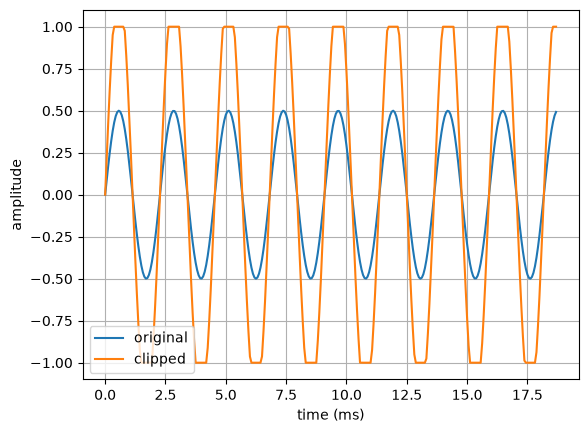

In [4]:
peak, rms = peak_and_rms(sine)
print("peak dBFS:", amplitude_db(peak, reference=1.0))
print("RMS dBFS:", amplitude_db(rms, reference=1.0))

clipped = np.clip(2.5 * sine, -1.0, 1.0)
print("clipped sample ratio:", np.mean(np.abs(clipped) >= 0.999))
plt.plot(t[:300] * 1000, sine[:300], label="original")
plt.plot(t[:300] * 1000, clipped[:300], label="clipped")
plt.xlabel("time (ms)"); plt.ylabel("amplitude"); plt.legend(); plt.grid(True); plt.show()


## 分层练习：不要一次做完

### A. 直觉与单位（每题 1 分）

1. 不看上文，用一句话定义：峰值。
2. 为 `RMS` 写出单位；如果它没有单位，要明确说明。
3. 举一个生活中的例子解释 `功率`。
4. 画图说明 `dB` 增大时，横轴或纵轴怎样变化。

### B. 数字与预测（每题 2 分）

5. 自己构造一个包含具体数字的计算例子，并标出每一步单位。
6. 把本课一个参数改成 0.5 倍和 2 倍；运行前先画出预期图形。
7. 找出一个“代码能运行，但物理含义错误”的输入，解释为什么错误。
8. 用 `shape / dtype / min / max` 四项审计本课最重要的数组。

### C. 实现与迁移（每题 3 分）

9. 从空白实现：**实现 peak_and_rms 与 amplitude_db，并解释零幅度的处理策略**，不能复制上面的函数。
10. 为实现写正常、边界和错误输入三类测试。
11. 换一组参数或换一条音频，验证结论是否仍成立。
12. 用 90 秒向没学过编程的人解释本课，只允许使用两个术语，并必须包含一个数字例子。

满分 24 分。达到 19 分且第 9～10 题完成，才建议继续；15～18 分次日重做；低于 15 分先回到图和单位。


## 最小掌握门禁

- [ ] 我能把本课每个量说成“含义 + 单位 + 数组表示”。
- [ ] 我能在运行前预测参数变化的方向。
- [ ] 我能从空白完成核心实现并覆盖边界输入。
- [ ] 我能说出一个常见误解，以及用什么证据推翻它。
- [ ] 我已把错题写入根目录 `LEARNING_LOG.md`，并安排明天、7 天、30 天复习。

下一步：音频基础 4：采样、量化、PCM、位深与通道。
